In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

dataset_path = "../../datasets/food-101/images"

print(os.path.exists(dataset_path))

True


In [28]:
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Save class names here
class_names = validation_dataset.class_names

AUTOTUNE = tf.data.AUTOTUNE
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print(len(class_names))
print(class_names[:10])

Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [29]:
model = load_model("../saved_models/mobilenetv2_finetuned.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [30]:
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

632/632 ━━━━━━━━━━━━━━━━━━━━ 375s 587ms/step - accuracy: 0.7381 - loss: 1.0156
Validation Loss     : 1.0156
Validation Accuracy : 0.7381


In [31]:
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Prediction Completed")
print("Total Labels:", len(y_true))
print("Total Predictions:", len(y_pred))

Prediction Completed
Total Labels: 20200
Total Predictions: 20200


In [32]:
print("Unique Classes :", len(np.unique(y_true)))
print("Minimum Label :", min(y_true))
print("Maximum Label :", max(y_true))

Unique Classes : 101
Minimum Label : 0
Maximum Label : 100


In [33]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                         precision    recall  f1-score   support

              apple_pie     0.5024    0.4907    0.4965       214
         baby_back_ribs     0.7090    0.7900    0.7473       219
                baklava     0.7523    0.8677    0.8059       189
         beef_carpaccio     0.7725    0.8372    0.8036       215
           beef_tartare     0.8014    0.5879    0.6783       199
             beet_salad     0.6768    0.6091    0.6411       220
               beignets     0.7437    0.8894    0.8101       199
               bibimbap     0.8645    0.8565    0.8605       216
          bread_pudding     0.4081    0.5968    0.4847       186
      breakfast_burrito     0.6607    0.6549    0.6578       226
             bruschetta     0.6810    0.6560    0.6682       218
           caesar_salad     0.7421    0.8241    0.7810       199
                cannoli     0.8448    0.8258    0.8352       178
          caprese_salad     0.7294    0.6458    0.6851       192
            carrot_cake 

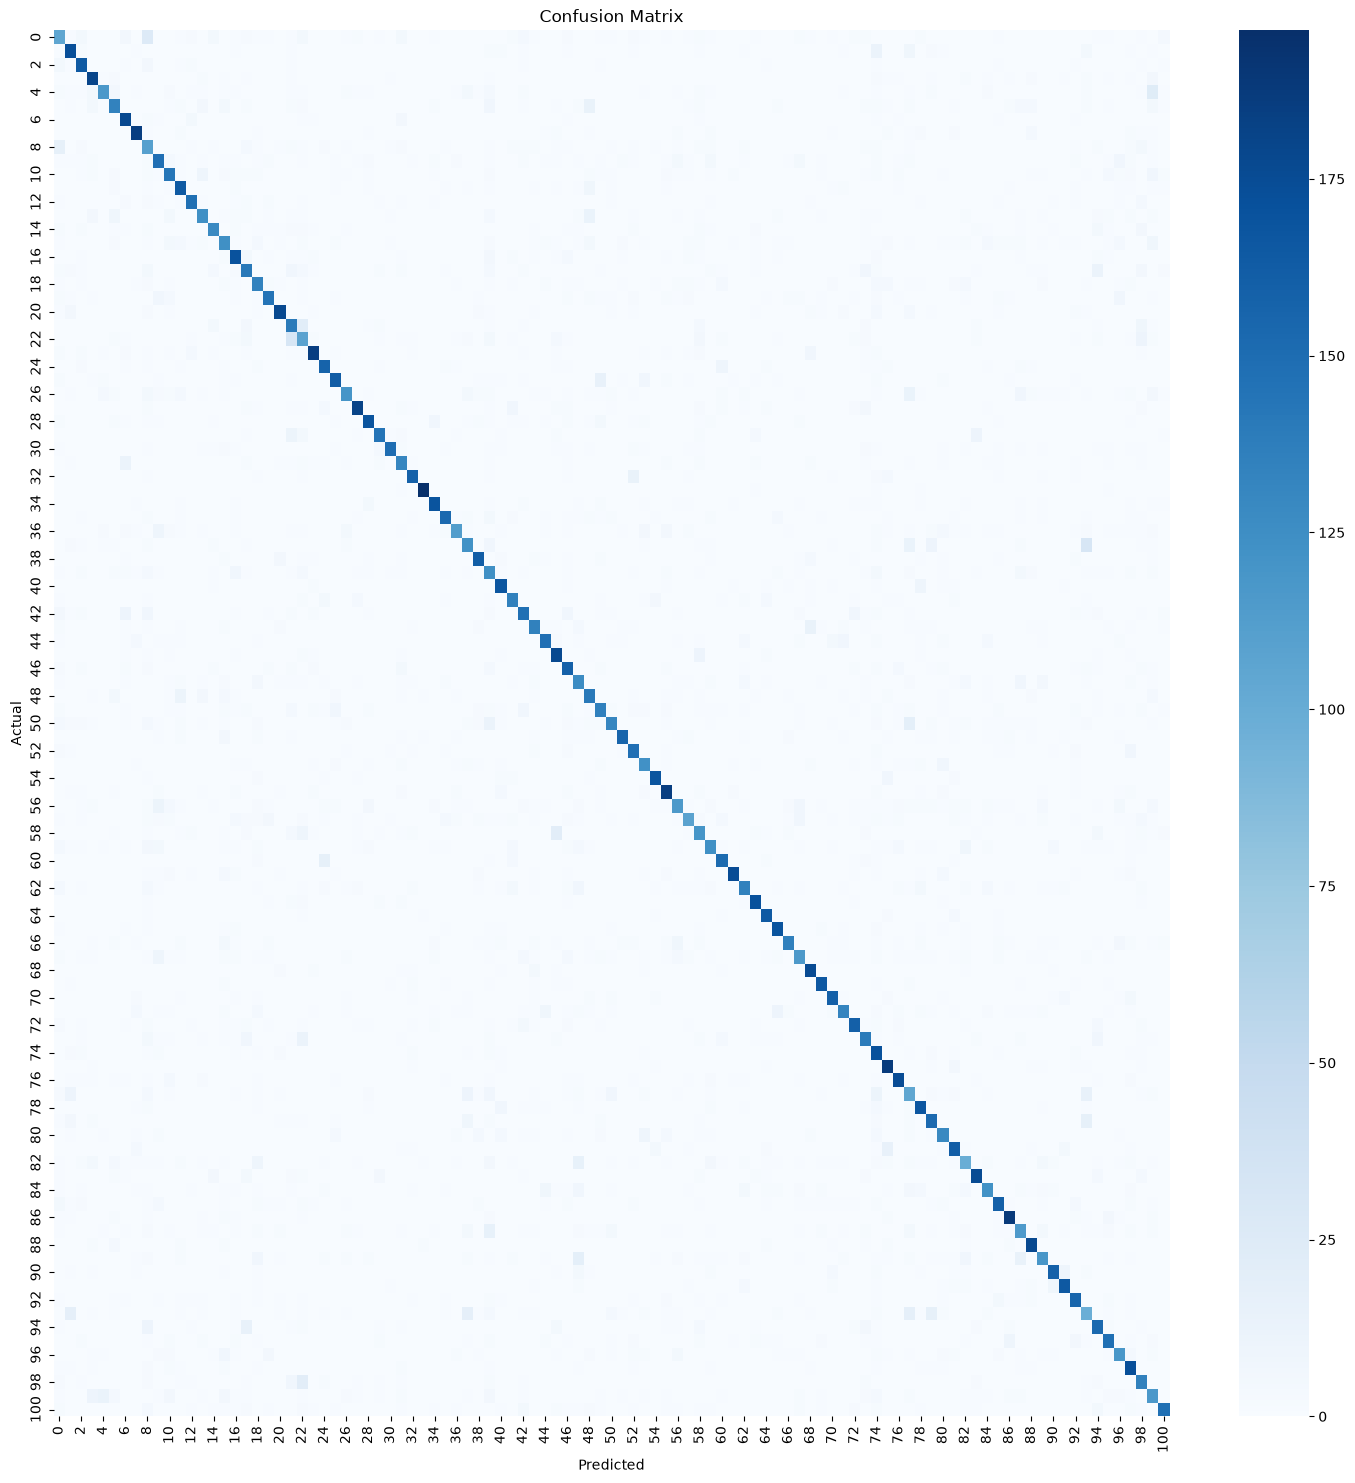

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 18))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()